In [17]:
import glob
import os 
import numpy as np
from tqdm import tqdm
import skimage

In [53]:
root_folder = "/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame"
old_prefix = "expanded_frame"
new_prefix = "expanded_frame_wih_fluid_fraction"
new_root_folder = root_folder.replace(old_prefix, new_prefix)
os.makedirs(new_root_folder, exist_ok=True)

In [5]:
all_folders = glob.glob(os.path.join( "/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame", '**/*npy'), recursive = True)

In [13]:
# np.load(all_folders[0]).shape
for file in tqdm(all_folders):
    assert len(np.load(file).shape) == 2

  0%|          | 0/88199 [00:00<?, ?it/s]

100%|██████████| 88199/88199 [00:49<00:00, 1770.82it/s]


In [14]:
from scipy.ndimage.morphology import distance_transform_bf

import matplotlib.pyplot as plt
def fill_keyhole(temp, borderline = 293, plate_height = 30, plot = False):
    '''
    Temp: Three dimensional temperature array
    '''
    temp = np.array(temp,dtype = float)[:, :plate_height]

    labeled_image = skimage.measure.label(temp>borderline, background = 1)
    # plt.imshow(labeled_image)
    # plt.title('label')
    # plt.show()
    props = skimage.measure.regionprops(labeled_image)
    volume = [prop.area for prop in props]
    
    idx_background = np.argmax(volume)
    for index, prop in enumerate(props):

        bbox = prop.bbox
        if bbox[-1] < temp.shape[-1]:
            continue
        if index == idx_background:
            continue
        else:
            temp[labeled_image == prop.label] = 10000
    if plot:
        plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
        
        plt.imshow(temp.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.title("Melt Pool, Keyhole Filled")
        plt.axis('off')
        plt.show()
        # plt.imshow(temp.T, origin  = 'lower')
        # plt.show()
    return temp
def extract_keyhole_temperatures(sample, plate_height, plot= False):

    if plot:
        plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
        
        plt.imshow(sample[:, :plate_height].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.title("Melt Pool")
        plt.axis('off')
        plt.show()
    temp_2d = fill_keyhole(sample, borderline = 1000, plate_height = 30)
    if plot:
        plt.imshow(temp_2d.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.title('filled')
        plt.show()
    criterion = np.logical_and(distance_transform_bf(temp_2d<5000)<1.1 , distance_transform_bf(temp_2d<5000)>0)
    filtered_temperatures = criterion*temp_2d
    temperature_values = filtered_temperatures[filtered_temperatures>0]
    if plot:
        plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
        plt.axis('off')
        plt.title('Keyhole Boundary Temperature Values')
        plt.imshow((criterion*temp_2d).T, origin = 'lower', vmin = 293, vmax = 5000, cmap ='jet')
        plt.show()
    return temperature_values
def get_fluid_fraction(temperature, plate_height = 30):
    temp_2d = fill_keyhole(temperature, borderline = 1000, plate_height = plate_height)
    above_plate = temperature[:, plate_height:]
    criterion_2 = above_plate > 300
    criterion_1 = temp_2d<8000
    fluid_fraction = np.hstack((criterion_1, criterion_2))
    return fluid_fraction

In [15]:

# plt.imshow(get_fluid_fraction(gts[3][0][0], plate_height = 30).T, origin = 'lower')
# plt.colorbar()  

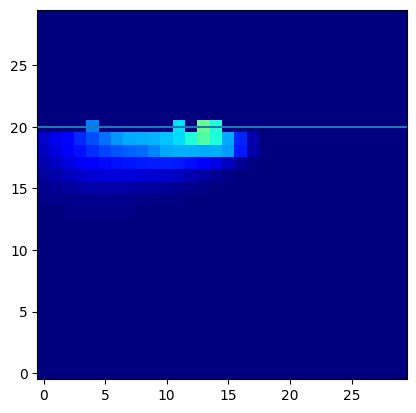

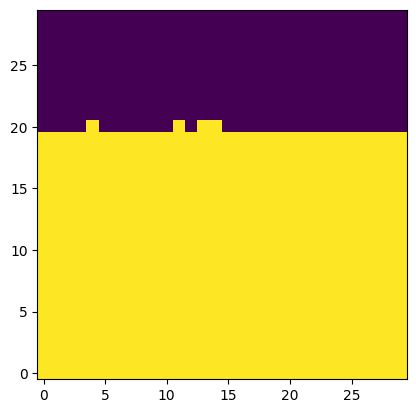

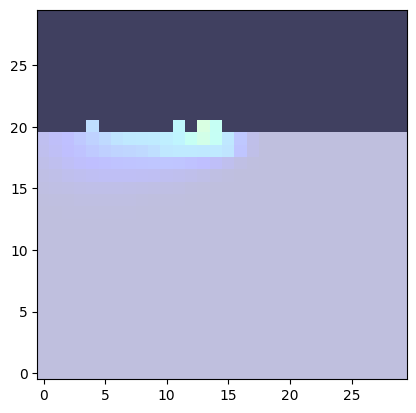

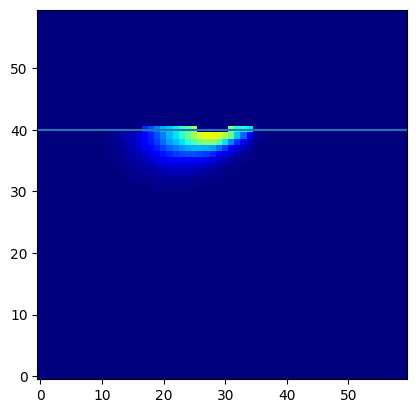

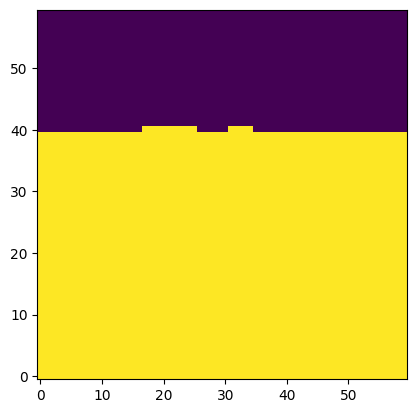

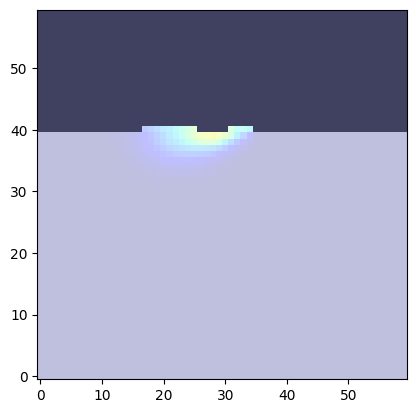

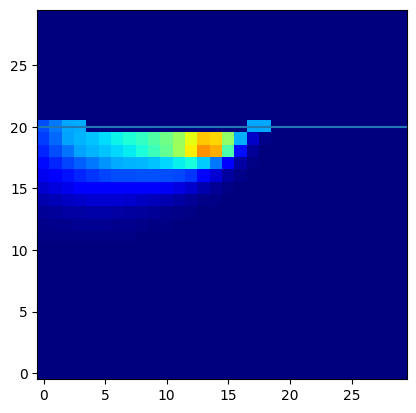

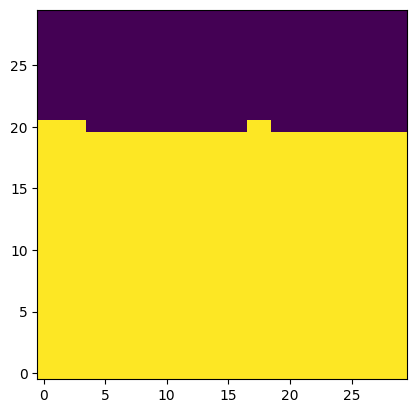

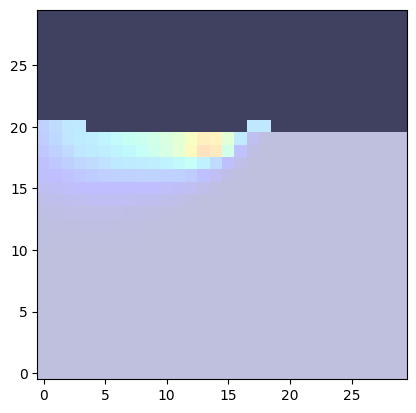

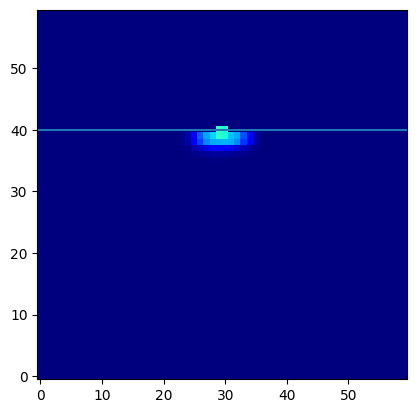

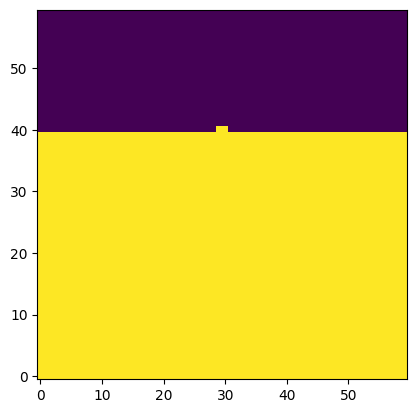

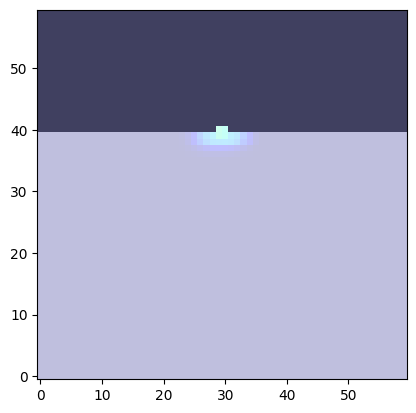

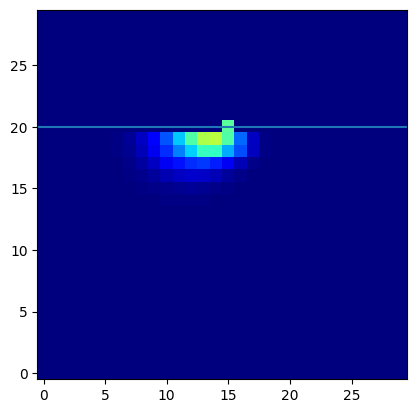

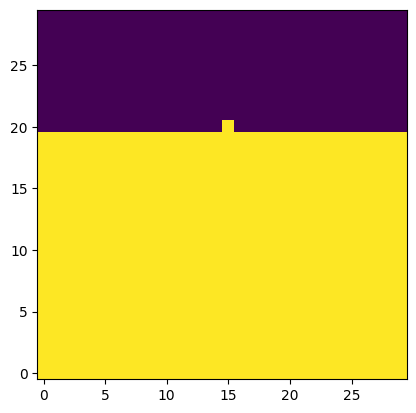

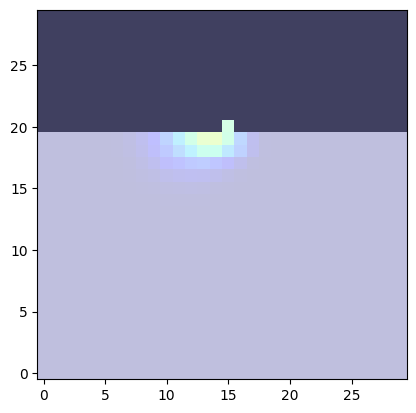

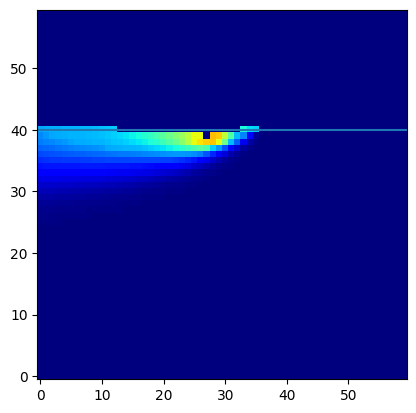

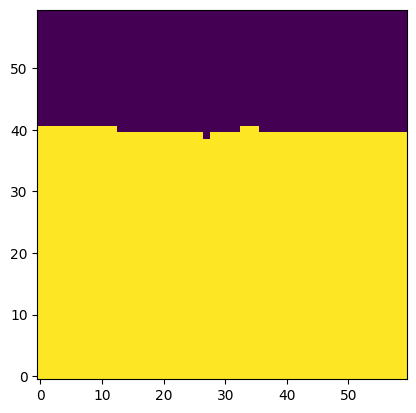

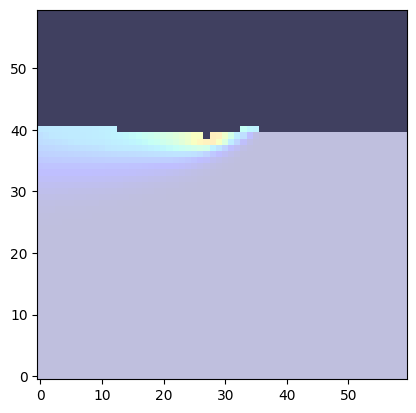

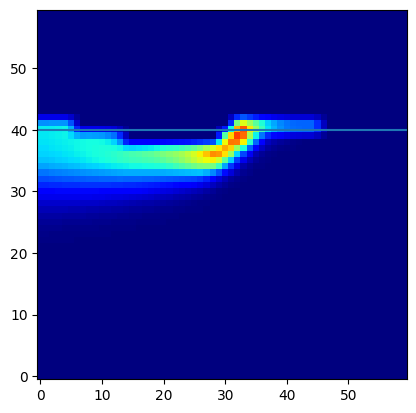

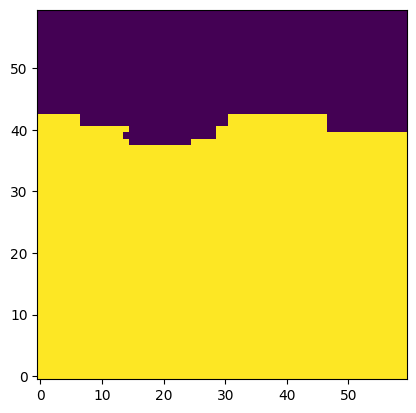

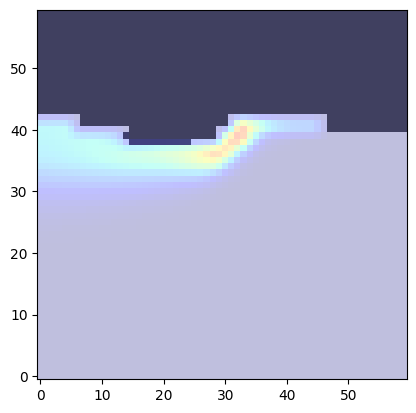

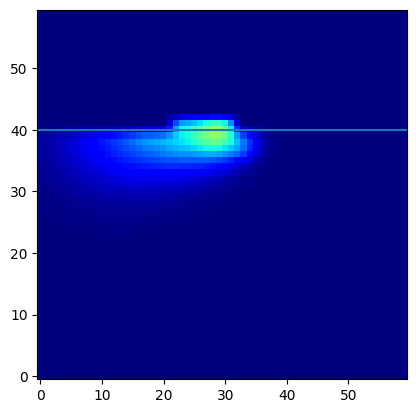

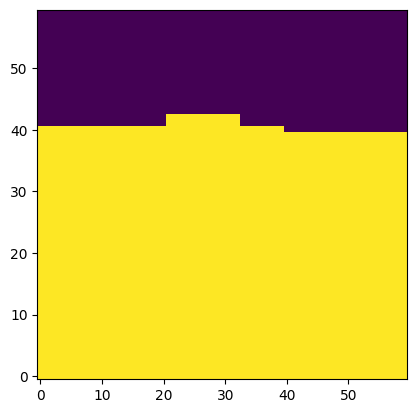

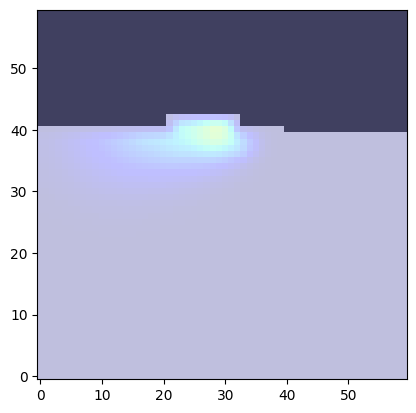

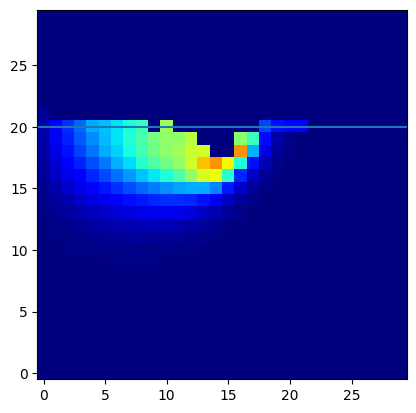

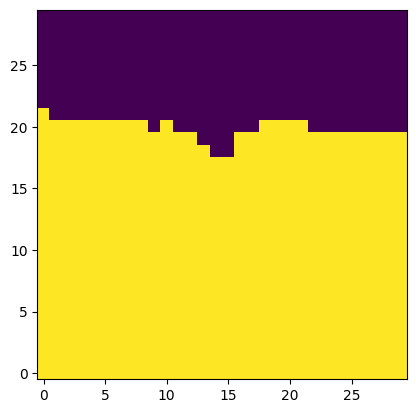

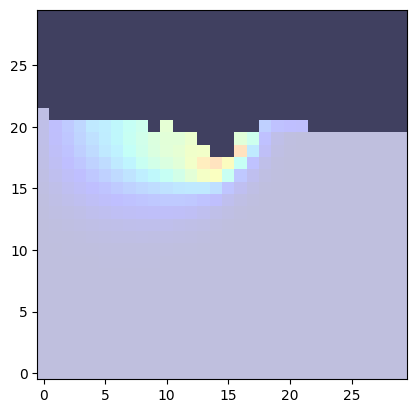

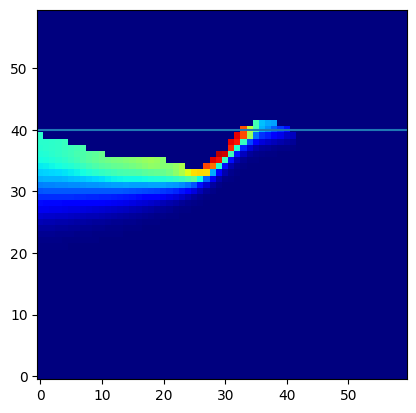

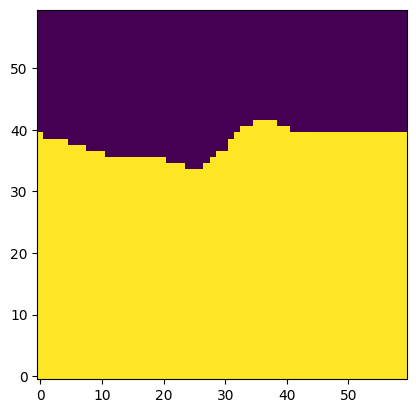

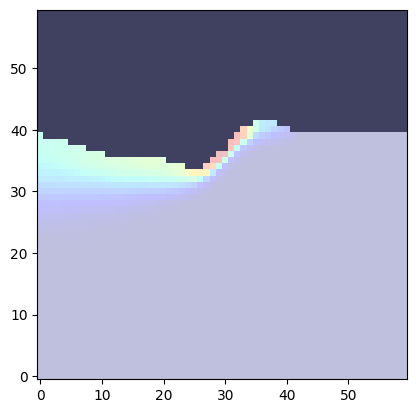

In [42]:
# _, filtered_contour, pores = find_keyhole_boundary(temp_2d, threshold = 1700, plate_height = 30)
for i in range(10):
    sample_index = np.random.randint(0, len(all_folders)) 
    temperature_sample = np.load(all_folders[sample_index])
    if np.shape(temperature_sample)[-1] == 30:
        # LR sample
        plate_height = 20
    elif np.shape(temperature_sample)[-1] == 60:
        # HR sample
        plate_height = 40
    else:
        print("Shape not recognized")
    plt.imshow(temperature_sample.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
    plt.axhline(plate_height)
    plt.show()
    fluid_fraction = get_fluid_fraction(temperature_sample, plate_height = plate_height)
    # plt.imshow(get_fluid_fraction(np.load(all_folders[0]), plate_height = 30))
    plt.imshow(fluid_fraction.T, origin = 'lower')
    plt.show()
    plt.imshow(temperature_sample.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000, alpha = 0.5)
    plt.imshow(fluid_fraction.T, origin = 'lower', alpha = 0.5, cmap = 'gray')
    plt.show()

In [48]:
np.dstack([temperature_sample, fluid_fraction])

array([[[299.14999,   1.     ],
        [299.14999,   1.     ],
        [299.14999,   1.     ],
        ...,
        [299.14999,   0.     ],
        [299.14999,   0.     ],
        [299.14999,   0.     ]],

       [[299.14999,   1.     ],
        [299.14999,   1.     ],
        [299.14999,   1.     ],
        ...,
        [299.14999,   0.     ],
        [299.14999,   0.     ],
        [299.14999,   0.     ]],

       [[299.14999,   1.     ],
        [299.14999,   1.     ],
        [299.14999,   1.     ],
        ...,
        [299.14999,   0.     ],
        [299.14999,   0.     ],
        [299.14999,   0.     ]],

       ...,

       [[299.14999,   1.     ],
        [299.14999,   1.     ],
        [299.14999,   1.     ],
        ...,
        [299.14999,   0.     ],
        [299.14999,   0.     ],
        [299.14999,   0.     ]],

       [[299.14999,   1.     ],
        [299.14999,   1.     ],
        [299.14999,   1.     ],
        ...,
        [299.14999,   0.     ],
        [299.14999

In [50]:
all_folders[0].replace('expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame', 'expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction')

'/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/dev/HR/power100velocity1350/_1063.npy'

  0%|          | 0/88199 [00:00<?, ?it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/dev/HR/power100velocity1350/_1002.npy


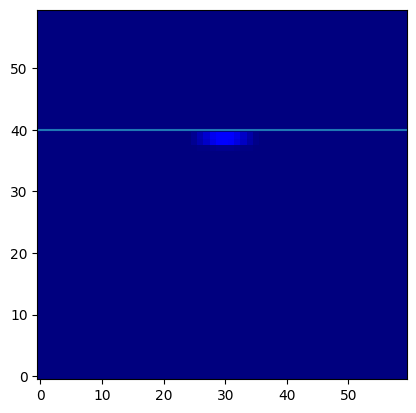

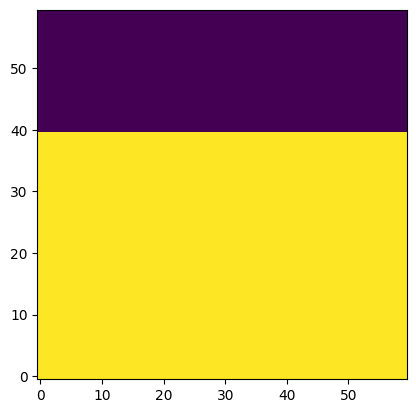

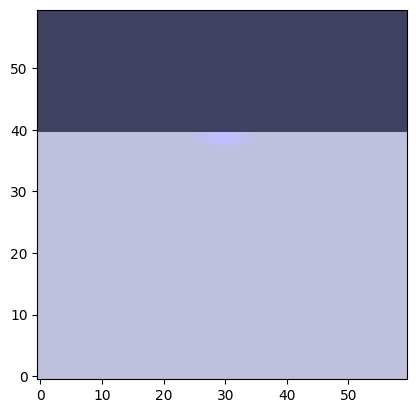

  6%|▌         | 5010/88199 [00:12<02:44, 506.54it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/dev/LR/direct/1x/power280velocity800/_1055.npy


 11%|█▏        | 9990/88199 [00:22<02:55, 445.78it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/test/HR/power190velocity900/_1042.npy


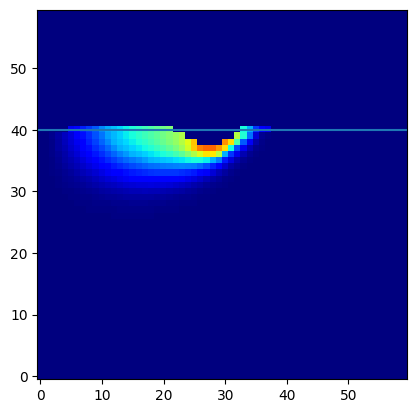

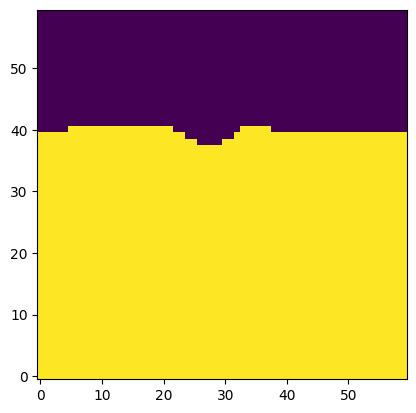

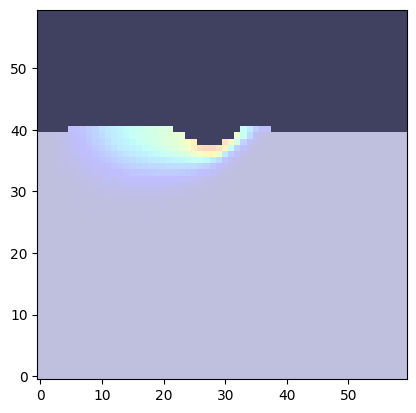

 17%|█▋        | 15101/88199 [00:33<02:13, 547.22it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/test/LR/direct/1x/power250velocity750/_1037.npy


 23%|██▎       | 19954/88199 [00:43<02:23, 475.06it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/test/LR/direct/2x/power310velocity100/_1032.npy


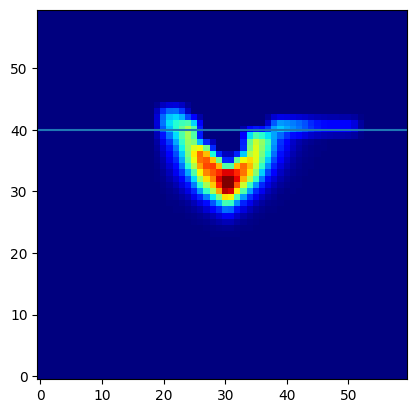

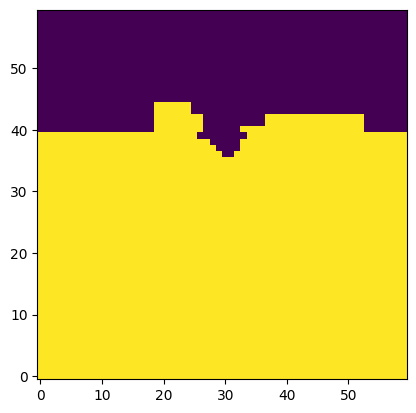

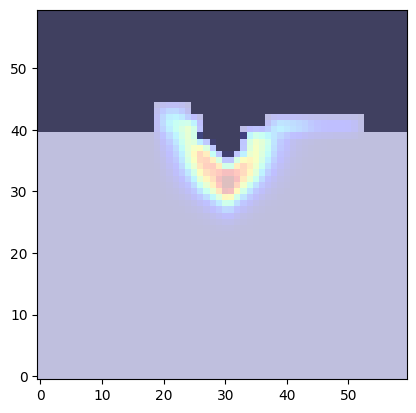

 28%|██▊       | 25067/88199 [00:54<02:28, 423.95it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/HR/power130velocity300/_1040.npy


 34%|███▍      | 29959/88199 [01:05<02:06, 460.53it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/HR/power190velocity600/_1093.npy


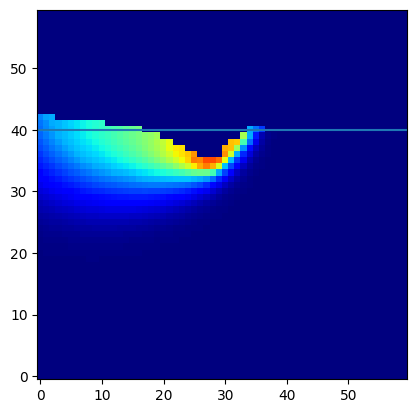

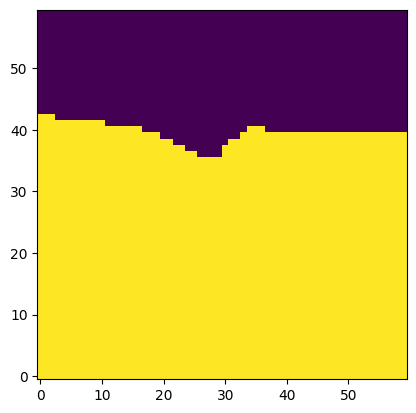

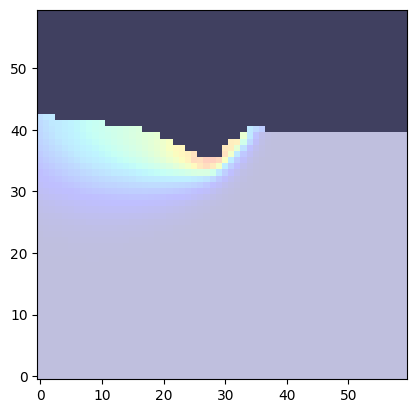

 40%|███▉      | 35051/88199 [01:16<01:55, 458.40it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/HR/power280velocity1000/_1049.npy


 45%|████▌     | 39957/88199 [01:26<01:42, 469.93it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/HR/power340velocity150/_1005.npy


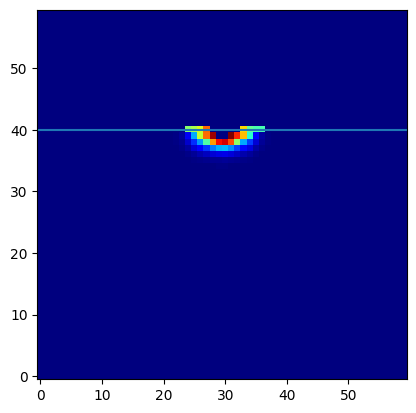

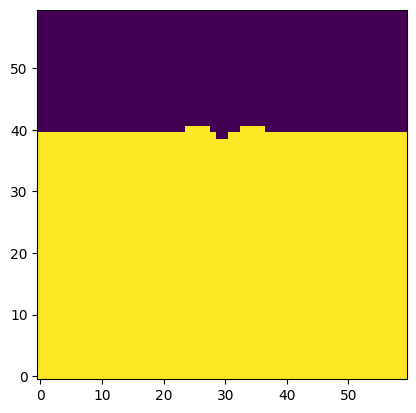

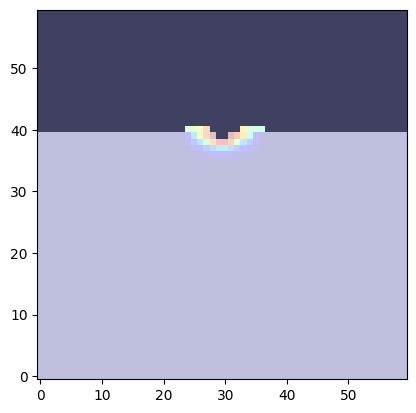

 51%|█████     | 45074/88199 [01:38<01:20, 534.02it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/1x/power100velocity250/_1013.npy


 57%|█████▋    | 49995/88199 [01:47<01:06, 575.31it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/1x/power160velocity750/_1066.npy


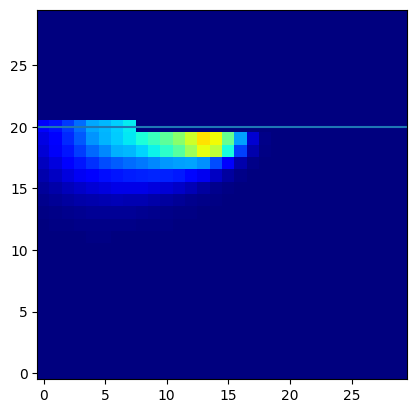

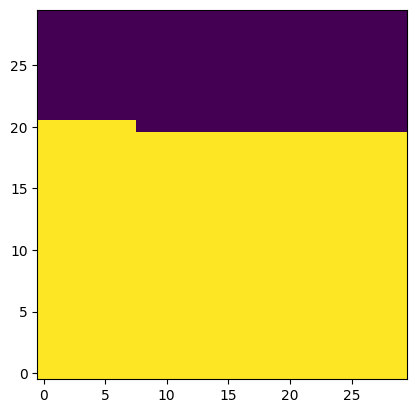

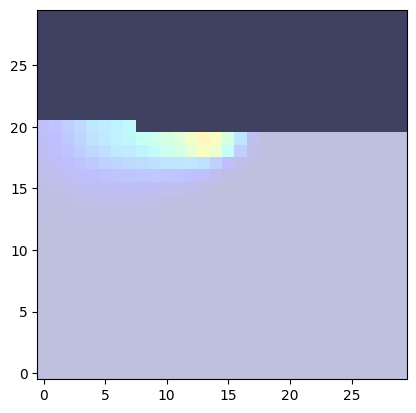

 62%|██████▏   | 55074/88199 [01:57<01:02, 525.80it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/1x/power250velocity1050/_1022.npy


 68%|██████▊   | 59994/88199 [02:07<00:56, 495.08it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/1x/power310velocity150/_1075.npy


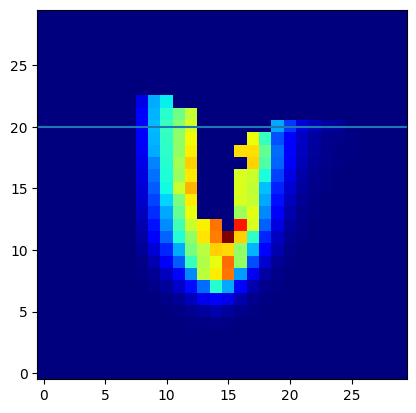

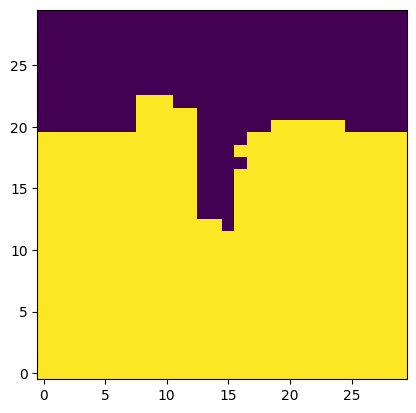

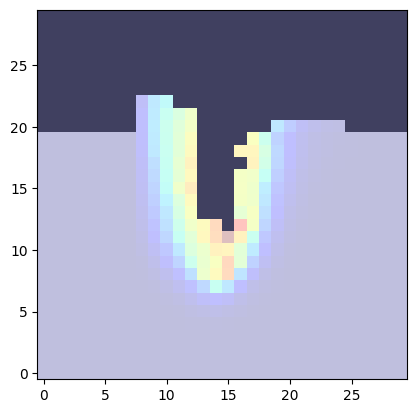

 74%|███████▍  | 65094/88199 [02:17<00:40, 577.53it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/1x/power430velocity1250/_1031.npy


 79%|███████▉  | 69985/88199 [02:27<00:38, 470.26it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/2x/power130velocity900/_1039.npy


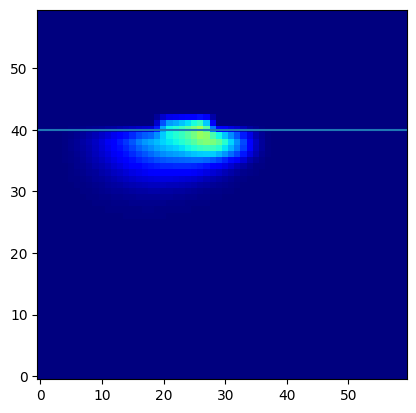

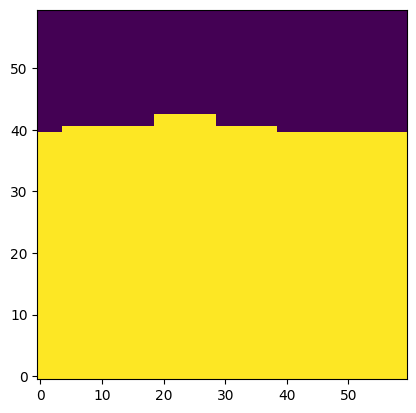

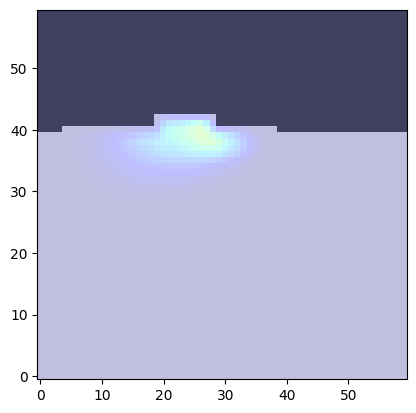

 85%|████████▌ | 75082/88199 [02:39<00:27, 476.37it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/2x/power220velocity1050/_1092.npy


 91%|█████████ | 79985/88199 [02:49<00:18, 441.93it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/2x/power280velocity300/_1048.npy


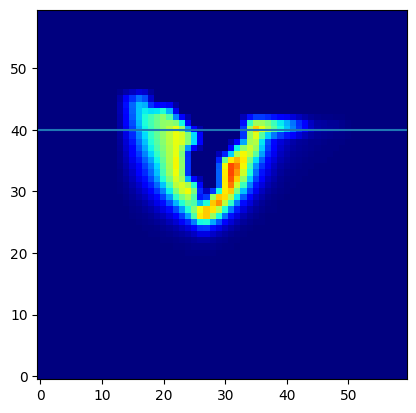

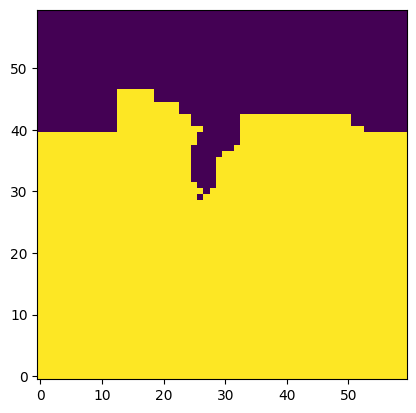

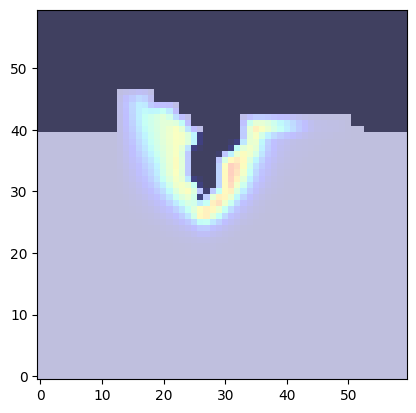

 96%|█████████▋| 85077/88199 [03:01<00:06, 462.85it/s]

/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction/train/LR/direct/2x/power400velocity1250/_1004.npy


100%|██████████| 88199/88199 [03:08<00:00, 468.72it/s]


In [67]:
all_folders_sorted = sorted(all_folders)
for i, file in enumerate(tqdm(all_folders_sorted)):
    temperature_sample = np.load(file)
    if np.shape(temperature_sample)[-1] == 30:
        # LR sample
        plate_height = 20
    elif np.shape(temperature_sample)[-1] == 60:
        # HR sample
        plate_height = 40
    else:
        print("Shape not recognized")
    fluid_fraction = get_fluid_fraction(temperature_sample, plate_height = plate_height)
    fluid_fraction = np.expand_dims(fluid_fraction, axis = 0)
    temperature_sample = np.expand_dims(temperature_sample, axis = 0)
    new_file = file.replace('expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame', 'expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame_fluid_fraction')
    if not os.path.exists(os.path.dirname(new_file)):
        os.makedirs(os.path.dirname(new_file))
    np.save(new_file, np.dstack([temperature_sample[0], fluid_fraction[0]]))
    # print(new_file)
    if i % 5000 == 0:
        print(new_file)
    if i % 10000 == 0:
        plt.imshow(temperature_sample[0].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.axhline(plate_height)
        plt.show()
        plt.imshow(fluid_fraction[0].T, origin = 'lower')
        plt.show()
        plt.imshow(temperature_sample[0].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000, alpha = 0.5)
        plt.imshow(fluid_fraction[0].T, origin = 'lower', alpha = 0.5, cmap = 'gray')
        plt.show()

In [66]:
np.dstack([temperature_sample[0], fluid_fraction[0]])[:,:, None].shape

(60, 60, 1, 2)

In [61]:
fluid_fraction.shape

(1, 60, 60)